In [1]:
# !pip install wandb -q
# !pip install timm -q
# !pip install torchvision

In [2]:
# Log in to your W&B account
# import wandb
#import random
# import math
# import os

In [3]:
import random
import math
import os, json, time, warnings
import wandb
import numpy as np
import pandas as pd
from PIL import Image
 
import torch
import torch.nn as nn
 
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR #baseline
from torchvision import transforms #for iamge preprocessing, e.g. resize, augmentation etc
 
from sklearn.model_selection import GroupShuffleSplit #for lesion_id split later
 
warnings.filterwarnings("ignore")
print("Imports OK")
import subprocess, zipfile
 
# PATHS 

DATA_ROOT = "/scratch/wpl3a/isic2019"

TEST_INPUT = f"{DATA_ROOT}/ISIC_2019_Test_Input"

TRAIN_INPUT = f"{DATA_ROOT}/ISIC_2019_Training_Input"

CKPT_DIR  = "/scratch/wpl3a/isic2019/checkpoints"

os.makedirs(DATA_ROOT, exist_ok=True)
 
BASE_URL = "https://isic-archive.s3.amazonaws.com/challenges/2019"
 

Imports OK


In [4]:
os.environ["WANDB_NOTEBOOK_NAME"] = "mbv3-small.ipynb"
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/wpl3a/.netrc.
wandb: Currently logged in as: wpl3a (vrb9e-university-of-virginia-school-of-data-science) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### Download and unzip ISIC dataset

In [5]:
# Download CSVs & zips 
DOWNLOADS = [
    (f"{BASE_URL}/ISIC_2019_Training_GroundTruth.csv", f"{DATA_ROOT}/train_gt.csv"),
    (f"{BASE_URL}/ISIC_2019_Training_Metadata.csv",    f"{DATA_ROOT}/train_meta.csv"),
    (f"{BASE_URL}/ISIC_2019_Test_GroundTruth.csv",     f"{DATA_ROOT}/test_gt.csv"),
    (f"{BASE_URL}/ISIC_2019_Training_Input.zip",       f"{DATA_ROOT}/train_imgs.zip"),
    (f"{BASE_URL}/ISIC_2019_Test_Input.zip",           f"{DATA_ROOT}/test_imgs.zip"),
]

# If already downloaded, do not download and unzip!!
if not len([f for f in os.listdir(TEST_INPUT) if f.endswith('.jpg')]) == 8238 and \
    len([f for f in os.listdir(TRAIN_INPUT) if f.endswith('.jpg')]) == 25331:
    for url, dest in DOWNLOADS:
            print(f"Downloading {os.path.basename(dest)} ...")
            subprocess.run(
                ["curl", "--location", "--progress-bar",
                 "--retry", "3", "--retry-delay", "5",
                 "--output", dest, url],
                check=True,
            )
    # Unzip
    for zip_path, extract_dir in [
        (f"{DATA_ROOT}/train_imgs.zip", DATA_ROOT),
        (f"{DATA_ROOT}/test_imgs.zip",  DATA_ROOT),
    ]:
        print(f"Extracting {os.path.basename(zip_path)} ...")
        # Sanity check
        size_mb = os.path.getsize(zip_path) / (1024**2)
        print(f"  File size: {size_mb:.1f} MB")
        if size_mb < 1:
            raise RuntimeError(f"File too small — download likely failed: {zip_path}")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)
        os.remove(zip_path)
        print(f"  Done & removed {os.path.basename(zip_path)}")
else:
    print('Data files already present, skipping download and unzip')


#for url, dest in DOWNLOADS:
#    print(f"Downloading {os.path.basename(dest)} ...")
#    subprocess.run(
#        ["curl", "--location", "--progress-bar",
#         "--retry", "3", "--retry-delay", "5",
#         "--output", dest, url],
#        check=True,
#    )

Data files already present, skipping download and unzip


In [6]:
'''
# Unzip
for zip_path, extract_dir in [
    (f"{DATA_ROOT}/train_imgs.zip", DATA_ROOT),
    (f"{DATA_ROOT}/test_imgs.zip",  DATA_ROOT),
]:
    print(f"Extracting {os.path.basename(zip_path)} ...")
    # Sanity check
    size_mb = os.path.getsize(zip_path) / (1024**2)
    print(f"  File size: {size_mb:.1f} MB")
    if size_mb < 1:
        raise RuntimeError(f"File too small — download likely failed: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    os.remove(zip_path)
    print(f"  Done & removed {os.path.basename(zip_path)}")
'''

'\n# Unzip\nfor zip_path, extract_dir in [\n    (f"{DATA_ROOT}/train_imgs.zip", DATA_ROOT),\n    (f"{DATA_ROOT}/test_imgs.zip",  DATA_ROOT),\n]:\n    print(f"Extracting {os.path.basename(zip_path)} ...")\n    # Sanity check\n    size_mb = os.path.getsize(zip_path) / (1024**2)\n    print(f"  File size: {size_mb:.1f} MB")\n    if size_mb < 1:\n        raise RuntimeError(f"File too small — download likely failed: {zip_path}")\n    with zipfile.ZipFile(zip_path, "r") as zf:\n        zf.extractall(extract_dir)\n    os.remove(zip_path)\n    print(f"  Done & removed {os.path.basename(zip_path)}")\n'

In [7]:
# Path 
TRAIN_DIR  = os.path.join(DATA_ROOT, "ISIC_2019_Training_Input")
TEST_DIR   = os.path.join(DATA_ROOT, "ISIC_2019_Test_Input")
TRAIN_CSV  = os.path.join(DATA_ROOT, "train_gt.csv")
TEST_CSV   = os.path.join(DATA_ROOT, "test_gt.csv")
TRAIN_META = os.path.join(DATA_ROOT, "train_meta.csv")
 
print("Done! Data ready.")

Done! Data ready.


In [8]:
Config = {
    # model
    "architecture": "mobilenet_v3_small",  # "resnet-50" | "mobilenetv3_small" | efficientnet_b0
    "pretrained":   True,              # False = train from scratch ablation
    "freeze_bb":    False,             # True = head-only training ablation
    "loss_fn":      "weighted_ce",      # "ce" | "weighted_ce | "focal"
    "augmentation": "standard",           # "none" | "geometric" | "color" | "standard"
    "img_size":     224,
    "batch_size":   32,
    "epochs":       30,
    "lr":           1e-4,
    "val_split":    0.20,
    "patience":     10,                #stop epoch if no improvement for 10
    "seed":         42,                #set_seed for reproducibility 
    "classes":      ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"],
    "min_delta":    .001,
}
Config["num_classes"] = len(Config["classes"])
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Config: {Config}")

Device: cuda
Config: {'architecture': 'mobilenet_v3_small', 'pretrained': True, 'freeze_bb': False, 'loss_fn': 'weighted_ce', 'augmentation': 'standard', 'img_size': 224, 'batch_size': 32, 'epochs': 30, 'lr': 0.0001, 'val_split': 0.2, 'patience': 10, 'seed': 42, 'classes': ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC'], 'min_delta': 0.001, 'num_classes': 8}


In [9]:
# seed value is in Config
def set_seed(seed=Config["seed"]):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
print(f"Seed set to {Config['seed']}")

Seed set to 42


In [10]:
#Dataset 

class ISICDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(f"{self.img_dir}/{row['image']}.jpg").convert("RGB")
        
        if self.transform:
            img = self.transform(img)
        label = int(row["label"])
        return img, label

def get_transforms(split):
    aug = Config["augmentation"]
    
    if split in ("val", "test"):
        return transforms.Compose([
            transforms.Resize((Config["img_size"], Config["img_size"])),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
    
    # Train transforms vary by augmentation setting in the Config code cell
    if aug == "none":
        aug_tfms = []
    elif aug == "geometric":
        aug_tfms = [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(degrees=15),
        ]
    elif aug == "color":
        aug_tfms = [
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        ]
    elif aug == "standard":
        aug_tfms = [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.RandomRotation(degrees=15),
        ]
    
    return transforms.Compose([
        transforms.Resize((Config["img_size"], Config["img_size"])),
        *aug_tfms,
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

In [11]:
### DUPLICATE WITH FOLLOWING CELL - FIX!!
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small

# Load pretrained model
model = mobilenet_v3_small(weights="IMAGENET1K_V1")

# Replace classifier for your dataset
num_classes = 10  # change this!
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

In [12]:
# import torch.nn as nn
# from torchvision.models import mobilenet_v3_small

def build_model(num_classes=Config["num_classes"]):
    weights = "IMAGENET1K_V1" if Config["pretrained"] else None
    
    model = mobilenet_v3_small(weights=weights)
    
    # Replace classifier
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    
    return model

model = build_model().to(device)

print(type(model))
print("Model loaded OK")

<class 'torchvision.models.mobilenetv3.MobileNetV3'>
Model loaded OK


In [13]:
#os.environ["WANDB_NOTEBOOK_NAME"] = "mbv3-small.ipynb"

# create tracked experiment run with labeled hyperparameters so you can analyze and compare results later

# entity → team/org/account in wandb
# project → folder for related experiments
# Run name → important for comparisons

# config={ ... } → logs hyperparameters:
#     model settings (architecture, pretrained, freeze_bb)
#     training settings (lr, batch_size, epochs)
#     early stopping (patience, min_delta)
#     reproducibility (seed)

# Stored so you can:
#     compare runs side-by-side
#     filter experiments (e.g., “show only focal loss runs”)
#     Reproduce results laterr
wandb.init(
    entity="vrb9e-university-of-virginia-school-of-data-science",
    project="ISIC2019",
    name=f"{Config['architecture']}_{Config['loss_fn']}_{Config['augmentation']}_pretrained{Config['pretrained']}",
    config={
        "architecture":  Config["architecture"],
        "loss_fn":       Config["loss_fn"],
        "augmentation":  Config["augmentation"],
        "pretrained":    Config["pretrained"],
        "freeze_bb":     Config["freeze_bb"],
        "img_size":      Config["img_size"],
        "batch_size":    Config["batch_size"],
        "epochs":        Config["epochs"],
        "lr":            Config["lr"],
        "val_split":     Config["val_split"],
        "patience":      Config["patience"],
        "seed":          Config["seed"],
        "min_delta":     Config["min_delta"],
    }
)

### TRAINING LOOP - ONE_EPOCH

In [14]:
import torch.nn.functional as F
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, roc_auc_score

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [15]:
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)                        
            probs   = F.softmax(outputs, dim=1)
            preds   = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())       

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc  = (all_preds == all_labels).mean()
    bacc = balanced_accuracy_score(all_labels, all_preds)

    # sensitivity & specificity per class
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(Config["num_classes"])))
    sensitivity, specificity, f1_per = [], [], []
    for i in range(Config["num_classes"]):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sensitivity.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
        specificity.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_per.append(2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0)

    # AUC per class
    auc_per_class = {}
    for i, cls in enumerate(Config["classes"]):
        try:
            auc_per_class[cls] = roc_auc_score((all_labels == i).astype(int), all_probs[:, i])
        except ValueError:
            auc_per_class[cls] = float("nan")

    return acc, bacc, np.array(sensitivity), np.array(specificity), np.array(f1_per), auc_per_class

In [16]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

# Convert label column
train_df["label"] = train_df[Config["classes"]].values.argmax(axis=1)
test_df["label"]  = test_df[Config["classes"]].values.argmax(axis=1)

# Train/val split stratified by label...to be improved later by adding patient-level split with lesion_id(GroupShuffleSplit)
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    train_df,
    test_size=Config["val_split"],
    stratify=train_df["label"],
    random_state=Config["seed"],
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 20264 | Val: 5067 | Test: 8238


In [17]:
#show class imabalnce in frequency table
counts        = train_df["label"].value_counts().sort_index()
CLASS_FREQ    = (counts / counts.sum()).to_dict()

print("Class frequencies:")

for name, df_ in [("TRAIN", train_df), ("VAL", val_df)]:
    labels = df_[Config["classes"]].values.argmax(axis=1)
    cnts   = np.bincount(labels, minlength=len(Config["classes"]))

    print(f"\n{name} ({len(df_)} images):")
    for i, c in enumerate(Config["classes"]):
        print(f"  {c:6s}: {cnts[i]:5d}  ({100*cnts[i]/len(df_):4.1f}%)")

Class frequencies:

TRAIN (20264 images):
  MEL   :  3618  (17.9%)
  NV    : 10300  (50.8%)
  BCC   :  2658  (13.1%)
  AK    :   694  ( 3.4%)
  BKL   :  2099  (10.4%)
  DF    :   191  ( 0.9%)
  VASC  :   202  ( 1.0%)
  SCC   :   502  ( 2.5%)

VAL (5067 images):
  MEL   :   904  (17.8%)
  NV    :  2575  (50.8%)
  BCC   :   665  (13.1%)
  AK    :   173  ( 3.4%)
  BKL   :   525  (10.4%)
  DF    :    48  ( 0.9%)
  VASC  :    51  ( 1.0%)
  SCC   :   126  ( 2.5%)


In [18]:
'''
# 10% subset TO REMOVE LATER
train_df = train_df.sample(frac=0.01, random_state=Config["seed"]).reset_index(drop=True)
val_df   = val_df.sample(frac=0.01,   random_state=Config["seed"]).reset_index(drop=True)
test_df  = test_df.sample(frac=0.01,  random_state=Config["seed"]).reset_index(drop=True)
print(f"Subset — train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")
'''

# Datasets
train_ds = ISICDataset(train_df, TRAIN_DIR, get_transforms("train"))
val_ds   = ISICDataset(val_df,   TRAIN_DIR, get_transforms("val"))
test_ds  = ISICDataset(test_df,  TEST_DIR,  get_transforms("test"))

# Dataloaders
train_loader = DataLoader(
    train_ds,
    batch_size=Config["batch_size"],
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=Config["batch_size"],
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=Config["batch_size"],
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [19]:
# compute class weights from standard ce so we can address class imbalance
# counts = train_df["label"].value_counts().sort_index()
counts = train_df["label"].value_counts().sort_index()
class_weights = (1.0 / counts).values
class_weights = class_weights / class_weights.sum() * len(class_weights)  # normalize
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

# build loss from Config
if Config["loss_fn"] == "weighted_ce":
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
elif Config["loss_fn"] == "ce":
    loss_fn = nn.CrossEntropyLoss()
else:
    raise ValueError(f"Unknown loss_fn: {Config['loss_fn']}")

In [20]:
print("Class counts:\n", counts)
print("Total samples:", counts.sum())
print("Raw inverse weights:", (1.0 / counts).values)
print("Normalized class weights:", class_weights)
print("Sum of weights:", class_weights.sum().item())
for cls, w in zip(counts.index, class_weights):
    print(f"Class {cls}: count={counts[cls]}, weight={w.item():.4f}")

print("Loss function:", loss_fn)
if hasattr(loss_fn, "weight") and loss_fn.weight is not None:
    print("Loss weights:", loss_fn.weight)

print("Unique labels:", sorted(train_df["label"].unique()))

Class counts:
 label
0     3618
1    10300
2     2658
3      694
4     2099
5      191
6      202
7      502
Name: count, dtype: int64
Total samples: 20264
Raw inverse weights: [2.76395799e-04 9.70873786e-05 3.76222724e-04 1.44092219e-03
 4.76417342e-04 5.23560209e-03 4.95049505e-03 1.99203187e-03]
Normalized class weights: tensor([0.1489, 0.0523, 0.2027, 0.7765, 0.2567, 2.8214, 2.6678, 1.0735],
       device='cuda:0')
Sum of weights: 8.0
Class 0: count=3618, weight=0.1489
Class 1: count=10300, weight=0.0523
Class 2: count=2658, weight=0.2027
Class 3: count=694, weight=0.7765
Class 4: count=2099, weight=0.2567
Class 5: count=191, weight=2.8214
Class 6: count=202, weight=2.6678
Class 7: count=502, weight=1.0735
Loss function: CrossEntropyLoss()
Loss weights: tensor([0.1489, 0.0523, 0.2027, 0.7765, 0.2567, 2.8214, 2.6678, 1.0735],
       device='cuda:0')
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


### Plot of class normalized weights vs class count
#### Visuals show minority class weights increase that addresses class imbalance

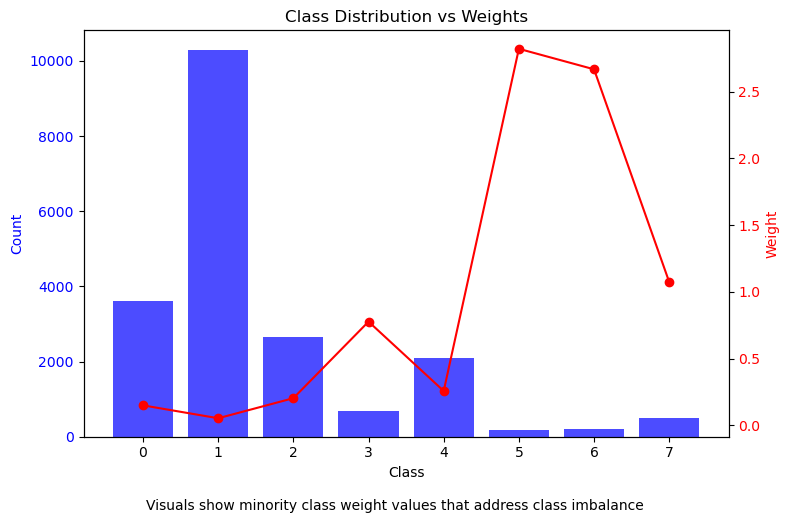

In [21]:
import matplotlib.pyplot as plt

# Counts (left axis)
labels = counts.index.tolist()
counts_values = counts.values
weights_values = class_weights.cpu().numpy()

fig, ax1 = plt.subplots(figsize=(8, 5))

# Counts (left axis) - BLUE
bars = ax1.bar(labels, counts_values, color='blue', alpha=0.7)
ax1.set_xlabel("Class")
ax1.set_ylabel("Count", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax1.set_title("Class Distribution vs Weights")

# Weights (right axis) - RED
ax2 = ax1.twinx()
ax2.plot(labels, weights_values, color='red', marker='o')
ax2.set_ylabel("Weight", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add annotation below x-axis label
fig.text(
    0.5, -0.03,
    "Plot indicates minority class weight values that address class imbalance",
    ha='center',
    fontsize=10
)

plt.tight_layout()
plt.show()

### TRAINING LOOP - EPOCHS

In [22]:
#os.environ["WANDB_NOTEBOOK_NAME"] = "mbv3-small.ipynb"
 
wandb.init(
    entity="vrb9e-university-of-virginia-school-of-data-science",
    project="ISIC2019",
    name=f"{Config['architecture']}_{Config['loss_fn']}_{Config['augmentation']}_pretrained{Config['pretrained']}",
    config={
        "architecture":  Config["architecture"],
        "loss_fn":       Config["loss_fn"],
        "augmentation":  Config["augmentation"],
        "pretrained":    Config["pretrained"],
        "freeze_bb":     Config["freeze_bb"],
        "img_size":      Config["img_size"],
        "batch_size":    Config["batch_size"],
        "epochs":        Config["epochs"],
        "lr":            Config["lr"],
        "val_split":     Config["val_split"],
        "patience":      Config["patience"],
        "seed":          Config["seed"],
    }
)

In [23]:
model     = build_model().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=Config["lr"])
scheduler = CosineAnnealingLR(optimizer, T_max=Config["epochs"], eta_min=1e-6)

best_bacc, best_epoch, no_improve = -1, 0, 0
history   = []
os.makedirs(CKPT_DIR, exist_ok=True)
ckpt_path = os.path.join(CKPT_DIR, "mobilenet_v3_small_best.pt")

print(f"Training | pretrained={Config['pretrained']} | loss={Config['loss_fn']}\n")
t0 = time.time()

for epoch in range(1, Config["epochs"] + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    acc, bacc, sensitivity, specificity, f1_per, auc_per_class = evaluate(model, val_loader, device)

    auc_macro = np.nanmean(list(auc_per_class.values()))
    
    log_dict = {
        "epoch":                 epoch,
        "train/loss":            train_loss,
        "val/acc":               acc,
        "val/bacc":              bacc,
        "val/sensitivity_macro": sensitivity.mean(),
        "val/specificity_macro": specificity.mean(),
        "val/f1_macro":          f1_per.mean(),
        "val/auc_macro":         auc_macro,
    }
    for i, cls in enumerate(Config["classes"]):
        log_dict[f"val/sensitivity_{cls}"] = sensitivity[i]
        log_dict[f"val/specificity_{cls}"] = specificity[i]
        log_dict[f"val/f1_{cls}"]          = f1_per[i]
        log_dict[f"val/auc_{cls}"]         = auc_per_class[cls]   # per-class AUC

    wandb.log(log_dict)
    
    history.append({
        "epoch":      epoch,
        "train_loss": train_loss,
        
        "val_acc":    acc,
        "val_bacc":   bacc,
        
        "val_sens":   float(sensitivity.mean()),
        "val_spec":   float(specificity.mean()),
        
        "val_f1":     float(f1_per.mean()),
        "val_auc":    float(auc_macro),
    })

    print(f"Epoch {epoch:3d}/{Config['epochs']} | loss={train_loss:.4f} | "
          f"acc={acc:.4f} | bacc={bacc:.4f} | "
          f"sens={sensitivity.mean():.4f} | spec={specificity.mean():.4f} | "
          f"f1={f1_per.mean():.4f} | auc={auc_macro:.4f}", end="")

    scheduler.step()

    # added value to allow for "minimal" improvement vs "min_delta = 0"
    if bacc > best_bacc + Config.get("min_delta", 0.001):
        best_bacc, best_epoch = bacc, epoch
        no_improve = 0
        torch.save(model.state_dict(), ckpt_path)
        print("saved")
    else:
        no_improve += 1
        print(f"  (no improve {no_improve}/{Config['patience']})")
        if no_improve >= Config["patience"]:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

# print AUC after last epoch
print("\nPer-class AUC:")
for cls in Config["classes"]:
    auc_val = auc_per_class.get(cls, float("nan"))
    print(f"  {cls}: {auc_val:.4f}", end=" | ")
print()

print(f"\nDone in {(time.time()-t0)/60:.1f} min")

print(f"Best   | epoch={best_epoch} | bacc={best_bacc:.4f}")
print(f"Final  | acc={acc:.4f} | bacc={bacc:.4f} | "
      f"sens={sensitivity.mean():.4f} | spec={specificity.mean():.4f} | "
      f"f1={f1_per.mean():.4f} | auc={auc_macro:.4f}")

history_path = os.path.join(CKPT_DIR, "history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
print(f"History saved to {history_path}")

Training | pretrained=True | loss=weighted_ce

Epoch   1/30 | loss=1.5626 | acc=0.5629 | bacc=0.5337 | sens=0.5337 | spec=0.9351 | f1=0.4073 | auc=0.8939saved
Epoch   2/30 | loss=1.2224 | acc=0.6416 | bacc=0.5732 | sens=0.5732 | spec=0.9446 | f1=0.4916 | auc=0.9169saved
Epoch   3/30 | loss=1.1011 | acc=0.6304 | bacc=0.6164 | sens=0.6164 | spec=0.9441 | f1=0.5123 | auc=0.9224saved
Epoch   4/30 | loss=1.0237 | acc=0.6823 | bacc=0.6448 | sens=0.6448 | spec=0.9495 | f1=0.5325 | auc=0.9338saved
Epoch   5/30 | loss=0.9546 | acc=0.6825 | bacc=0.6707 | sens=0.6707 | spec=0.9503 | f1=0.5615 | auc=0.9356saved
Epoch   6/30 | loss=0.9078 | acc=0.6759 | bacc=0.6679 | sens=0.6679 | spec=0.9498 | f1=0.5782 | auc=0.9319  (no improve 1/10)
Epoch   7/30 | loss=0.8525 | acc=0.6769 | bacc=0.6899 | sens=0.6899 | spec=0.9498 | f1=0.5455 | auc=0.9341saved
Epoch   8/30 | loss=0.7990 | acc=0.6978 | bacc=0.6993 | sens=0.6993 | spec=0.9524 | f1=0.5911 | auc=0.9381saved
Epoch   9/30 | loss=0.7521 | acc=0.6900 | b

In [24]:
'''
import random
import math
os.environ["WANDB_NOTEBOOK_NAME"] = "mbv3-small.ipynb"

# Launch 5 simulated experiments
total_runs = 5
for run in range(total_runs):
  # 1️. Start a new run to track this script
  wandb.init(
      # Set the project where this run will be logged
      project="basic-intro",
      # We pass a run name (otherwise it’ll be randomly assigned, like sunshine-lollypop-10)
      name=f"experiment_{run}",
      # Track hyperparameters and run metadata
      config={
      "learning_rate": 0.02,
      "architecture": "CNN",
      "dataset": "CIFAR-100",
      "epochs": 10,
      })

  # This simple block simulates a training loop logging metrics
  epochs = 10
  offset = random.random() / 5
  for epoch in range(2, epochs):
      acc = 1 - 2 ** -epoch - random.random() / epoch - offset
      loss = 2 ** -epoch + random.random() / epoch + offset

      # 2️. Log metrics from your script to W&B
      wandb.log({"acc": acc, "loss": loss})

  # Mark the run as finished
  wandb.finish()
'''

'\nimport random\nimport math\nos.environ["WANDB_NOTEBOOK_NAME"] = "mbv3-small.ipynb"\n\n# Launch 5 simulated experiments\ntotal_runs = 5\nfor run in range(total_runs):\n  # 1️. Start a new run to track this script\n  wandb.init(\n      # Set the project where this run will be logged\n      project="basic-intro",\n      # We pass a run name (otherwise it’ll be randomly assigned, like sunshine-lollypop-10)\n      name=f"experiment_{run}",\n      # Track hyperparameters and run metadata\n      config={\n      "learning_rate": 0.02,\n      "architecture": "CNN",\n      "dataset": "CIFAR-100",\n      "epochs": 10,\n      })\n\n  # This simple block simulates a training loop logging metrics\n  epochs = 10\n  offset = random.random() / 5\n  for epoch in range(2, epochs):\n      acc = 1 - 2 ** -epoch - random.random() / epoch - offset\n      loss = 2 ** -epoch + random.random() / epoch + offset\n\n      # 2️. Log metrics from your script to W&B\n      wandb.log({"acc": acc, "loss": loss})\n\n

In [25]:
'''
model     = build_model().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=Config["lr"])
scheduler = CosineAnnealingLR(optimizer, T_max=Config["epochs"], eta_min=1e-6)

best_bacc, best_epoch, no_improve = -1, 0, 0
history   = []
ckpt_path = os.path.join(CKPT_DIR, "mbv3-small_best.pt")

print(f"Training | pretrained={Config['pretrained']} | loss={Config['loss_fn']}\n")
t0 = time.time()

for epoch in range(1, Config["epochs"] + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    acc, bacc, sensitivity, specificity, f1_per, auc_per_class = evaluate(model, val_loader, device)

    auc_macro = np.nanmean(list(auc_per_class.values()))
    
    log_dict = {
        "epoch":                 epoch,
        "train/loss":            train_loss,
        "val/acc":               acc,
        "val/bacc":              bacc,
        "val/sensitivity_macro": sensitivity.mean(),
        "val/specificity_macro": specificity.mean(),
        "val/f1_macro":          f1_per.mean(),
        "val/auc_macro":         auc_macro,
    }
    for i, cls in enumerate(Config["classes"]):
        log_dict[f"val/sensitivity_{cls}"] = sensitivity[i]
        log_dict[f"val/specificity_{cls}"] = specificity[i]
        log_dict[f"val/f1_{cls}"]          = f1_per[i]
        log_dict[f"val/auc_{cls}"]         = auc_per_class[cls]   # per-class AUC


#os.environ["WANDB_NOTEBOOK_NAME"] = "mbv3-small.ipynb"
 
    wandb.init(
        entity="vrb9e-university-of-virginia-school-of-data-science",
        project="ISIC2019",
        name=f"{Config['architecture']}_{Config['loss_fn']}_{Config['augmentation']}_pretrained{Config['pretrained']}",
        config={
            "architecture":  Config["architecture"],
            "loss_fn":       Config["loss_fn"],
            "augmentation":  Config["augmentation"],
            "pretrained":    Config["pretrained"],
            "freeze_bb":     Config["freeze_bb"],
            "img_size":      Config["img_size"],
            "batch_size":    Config["batch_size"],
            "epochs":        Config["epochs"],
            "lr":            Config["lr"],
            "val_split":     Config["val_split"],
            "patience":      Config["patience"],
            "seed":          Config["seed"],
        }
    )

    wandb.log(log_dict)
    
    history.append({
        "epoch":      epoch,
        "train_loss": train_loss,
        
        "val_acc":    acc,
        "val_bacc":   bacc,
        
        "val_sens":   float(sensitivity.mean()),
        "val_spec":   float(specificity.mean()),
        
        "val_f1":     float(f1_per.mean()),
        "val_auc":    float(auc_macro),
    })

'''

'''
    print(f"Epoch {epoch:3d}/{Config['epochs']} | loss={train_loss:.4f} | "
          f"acc={acc:.4f} | bacc={bacc:.4f} | "
          f"sens={sensitivity.mean():.4f} | spec={specificity.mean():.4f} | "
          f"f1={f1_per.mean():.4f} | auc={auc_macro:.4f}", end="")
    
    scheduler.step()

    if bacc > best_bacc:
        best_bacc, best_epoch = bacc, epoch
        no_improve = 0
        torch.save(model.state_dict(), ckpt_path)
        print("saved")
    else:
        no_improve += 1
        print(f"  (no improve {no_improve}/{Config['patience']})")
        if no_improve >= Config["patience"]:
            print(f"\nEarly stopping at epoch {epoch}.")
            break
'''

print(f"\nDone in {(time.time()-t0)/60:.1f} min")

print(f"Best   | epoch={best_epoch} | bacc={best_bacc:.4f}")
print(f"Final  | acc={acc:.4f} | bacc={bacc:.4f} | "
      f"sens={sensitivity.mean():.4f} | spec={specificity.mean():.4f} | "
      f"f1={f1_per.mean():.4f} | auc={auc_macro:.4f}")

# print AUC after last epoch
print("\nPer-class AUC:")
for cls in Config["classes"]:
    auc_val = auc_per_class.get(cls, float("nan"))
    print(f"  {cls}: {auc_val:.4f}", end=" | ")
print()

history_path = os.path.join(CKPT_DIR, "history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
print(f"History saved to {history_path}")



Done in 190.3 min
Best   | epoch=19 | bacc=0.7481
Final  | acc=0.7523 | bacc=0.7437 | sens=0.7437 | spec=0.9595 | f1=0.6974 | auc=0.9539

Per-class AUC:
  MEL: 0.8967 |   NV: 0.9414 |   BCC: 0.9732 |   AK: 0.9672 |   BKL: 0.9244 |   DF: 0.9583 |   VASC: 0.9996 |   SCC: 0.9703 | 
History saved to /scratch/wpl3a/isic2019/checkpoints/history.json


### Weights and Bias Metrics

In [26]:
def print_benchmark(model, label="Model"):
    params_total     = sum(p.numel() for p in model.parameters())
    params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    size_mb          = params_total * 4 / 1024 ** 2  # float32

    # Inference speed
    model.eval()
    dummy = torch.randn(1, 3, 224, 224).to(device)
    with torch.no_grad():
        start = torch.cuda.Event(enable_timing=True)
        end   = torch.cuda.Event(enable_timing=True)
        start.record()
        for _ in range(50):
            model(dummy)
        end.record()
        torch.cuda.synchronize()
    inference_ms = start.elapsed_time(end) / 50

    # GFLOPs (requires thop)
    try:
        from thop import profile
        flops, _ = profile(model, inputs=(dummy,), verbose=False)
        gflops = flops / 1e9
    except:
        gflops = None

    bench = {
        "params_total":     params_total,
        "params_trainable": params_trainable,
        "size_mb":          round(size_mb, 2),
        "inference_ms":     round(inference_ms, 2),
        "gflops":           round(gflops, 4) if gflops else None
    }

    print(f"\n=== Benchmark: {label} ===")
    for k, v in bench.items():
        print(f"  {k}: {v}")

    return bench

 
wandb.init(
    entity="vrb9e-university-of-virginia-school-of-data-science",
    project="ISIC2019",
    name=f"{Config['architecture']}_{Config['loss_fn']}_{Config['augmentation']}_pretrained{Config['pretrained']}",
    config={
        "architecture":  Config["architecture"],
        "loss_fn":       Config["loss_fn"],
        "augmentation":  Config["augmentation"],
        "pretrained":    Config["pretrained"],
        "freeze_bb":     Config["freeze_bb"],
        "img_size":      Config["img_size"],
        "batch_size":    Config["batch_size"],
        "epochs":        Config["epochs"],
        "lr":            Config["lr"],
        "val_split":     Config["val_split"],
        "patience":      Config["patience"],
        "seed":          Config["seed"],
    }
)

model.load_state_dict(torch.load(ckpt_path, map_location=device))
bench = print_benchmark(model, label=f"mobilenet_v3_small ({Config['loss_fn']}, aug={Config['augmentation']})")
wandb.summary["benchmark/params_total"]     = bench["params_total"]
wandb.summary["benchmark/params_trainable"] = bench["params_trainable"]
wandb.summary["benchmark/size_mb"]          = bench["size_mb"]
wandb.summary["benchmark/inference_ms"]     = bench["inference_ms"]
wandb.summary["benchmark/gflops"]           = bench["gflops"]
wandb.summary["best_val_bacc"]              = best_bacc
wandb.summary["best_epoch"]                 = best_epoch
artifact = wandb.Artifact(
    name=f"efficientnet_b0_{Config['loss_fn']}_{Config['augmentation']}",
    type="model",
    description=f"Best checkpoint — val BACC {best_bacc:.4f} @ epoch {best_epoch}"
)
artifact.add_file(ckpt_path)
wandb.log_artifact(artifact)
print("Checkpoint artifact logged to W&B")
wandb.finish()
print("W&B run finished.")

# History saving
history_path = os.path.join(CKPT_DIR, "history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
print(f"History saved to {history_path}")

epoch,▁▁▁▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇██
train/loss,█▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▄▃▅▅▅▅▆▆▆▆▆▇▇▇▆████▇████████
val/auc_AK,▁▃▄▅▅▅▆▆▆▆▆▇▇▇▇▇█████████████
val/auc_BCC,▁▃▄▅▅▆▅▆▆▆▆▆▇▇▇▇▇████████████
val/auc_BKL,▁▅▄▆▆▅▆▆▇▇▇▇▇▇▇▇▇████████████
val/auc_DF,▁▄▆▇█▇▆▇█▇▆▅▆▆▇▅▇▇▆▆▆▆▆▆▅▅▆▆▆
val/auc_MEL,▁▄▄▅▆▅▅▆▆▆▆▇▇▇▇▆█████████████
val/auc_NV,▁▃▄▅▅▅▅▆▆▆▇▇▇▇▇▇▇████████████
val/auc_SCC,▁▂▄▅▆▅▅▅▆▆▆▇▆▇▇▆▇▇█▇█████████
+30,...



=== Benchmark: mobilenet_v3_small (weighted_ce, aug=standard) ===
  params_total: 1526056
  params_trainable: 1526056
  size_mb: 5.82
  inference_ms: 5.82
  gflops: None
Checkpoint artifact logged to W&B


benchmark/inference_ms,5.82
benchmark/params_total,1526056
benchmark/params_trainable,1526056
benchmark/size_mb,5.82
best_epoch,19
best_val_bacc,0.74806


W&B run finished.
History saved to /scratch/wpl3a/isic2019/checkpoints/history.json


In [27]:
import wandb
api = wandb.Api()

# run is specified by <entity>/<project>/<run_id>
run = api.run("vrb9e-university-of-virginia-school-of-data-science/ISIC2019/6ofwjybn")

# save the metrics for the run to a csv file
metrics_dataframe = run.history()
metrics_dataframe.to_csv("metrics.csv")